# Testing stuff
Here I am testing python modules and data processing techniques, to get familiar with tools.

In [20]:
import torch

torch.manual_seed(69)

print("Testing concatenations....")
a = torch.randn(5,3)
b = torch.randn(5,3)
print("A", a)
print("B", b)
print("Concatenated:", torch.cat((a, b), dim=1))

Testing concatenations....
A tensor([[-0.5259, -2.6043, -0.6448],
        [ 1.4356, -0.5796, -0.7254],
        [ 1.6112, -0.0703,  0.4757],
        [-0.3330, -0.0810, -1.2897],
        [-1.1969,  0.6707, -1.2555]])
B tensor([[-1.1164,  1.2523, -1.5541],
        [-1.4058, -0.3329, -0.2117],
        [-0.4752,  0.0606,  1.9731],
        [ 0.1399,  0.1372, -2.0599],
        [ 1.1843,  0.4051, -0.0157]])
Concatenated: tensor([[-0.5259, -2.6043, -0.6448, -1.1164,  1.2523, -1.5541],
        [ 1.4356, -0.5796, -0.7254, -1.4058, -0.3329, -0.2117],
        [ 1.6112, -0.0703,  0.4757, -0.4752,  0.0606,  1.9731],
        [-0.3330, -0.0810, -1.2897,  0.1399,  0.1372, -2.0599],
        [-1.1969,  0.6707, -1.2555,  1.1843,  0.4051, -0.0157]])


## Exploring candidate datasets for training

### IOTID20
Apparently, this dataset is imbalanced, gives mainly focus on mirai attacks. Benign traffic is a minority.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 625783 entries, 2019-07-25 03:25:53 to 2019-07-25 03:25:10
Data columns (total 81 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Src_Port           625783 non-null  int64  
 1   Dst_Port           625783 non-null  int64  
 2   Protocol           625783 non-null  int64  
 3   Flow_Duration      625783 non-null  int64  
 4   Tot_Fwd_Pkts       625783 non-null  int64  
 5   Tot_Bwd_Pkts       625783 non-null  int64  
 6   TotLen_Fwd_Pkts    625783 non-null  float64
 7   TotLen_Bwd_Pkts    625783 non-null  float64
 8   Fwd_Pkt_Len_Max    625783 non-null  float64
 9   Fwd_Pkt_Len_Min    625783 non-null  float64
 10  Fwd_Pkt_Len_Mean   625783 non-null  float64
 11  Fwd_Pkt_Len_Std    625783 non-null  float64
 12  Bwd_Pkt_Len_Max    625783 non-null  float64
 13  Bwd_Pkt_Len_Min    625783 non-null  float64
 14  Bwd_Pkt_Len_Mean   625783 non-null  float64
 15  Bwd_Pkt_Len_Std  

,Src_Port,Dst_Port,Protocol,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,...,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Category,Sub_Cat
Timestamp,,,,,,,,,,,,,,,,,,,,,
2019-07-25 03:25:53,10000,10101,17,75,1,1,982.0,1430.0,982.0,982.0,...,0.0,0.0,0.0,0.0,75.00,0.000000,75.0,75.0,Mirai,Mirai-Ackflooding
2019-05-26 22:11:06,2179,554,6,5310,1,2,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2655.00,2261.327486,4254.0,1056.0,DoS,DoS-Synflooding
2019-07-11 01:24:48,52727,9020,6,141,0,3,0.0,2806.0,0.0,0.0,...,0.0,0.0,0.0,0.0,70.50,0.707107,71.0,70.0,Scan,Scan Port OS
2019-09-04 03:58:17,52964,9020,6,151,0,2,0.0,2776.0,0.0,0.0,...,0.0,0.0,0.0,0.0,151.00,0.000000,151.0,151.0,Mirai,Mirai-Hostbruteforceg
2019-09-10 01:41:18,36763,1900,17,153,2,1,886.0,420.0,452.0,434.0,...,0.0,0.0,0.0,0.0,76.50,0.707107,77.0,76.0,Mirai,Mirai-Hostbruteforceg
2019-09-10 01:39:13,41980,443,6,157,2,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,78.50,6.363961,83.0,74.0,Mirai,Mirai-Hostbruteforceg
2019-07-25 03:21:01,60175,8899,17,139,20,1,640.0,32.0,32.0,32.0,...,0.0,0.0,0.0,0.0,6.95,1.669384,10.0,4.0,Mirai,Mirai-UDP Flooding
2019-07-11 01:52:37,41467,443,6,112,0,2,0.0,2896.0,0.0,0.0,...,0.0,0.0,0.0,0.0,112.00,0.000000,112.0,112.0,Scan,Scan Port OS
2019-07-25 03:21:13,60132,8899,17,86,1,1,32.0,32.0,32.0,32.0,...,0.0,0.0,0.0,0.0,86.00,0.000000,86.0,86.0,Mirai,Mirai-UDP Flooding


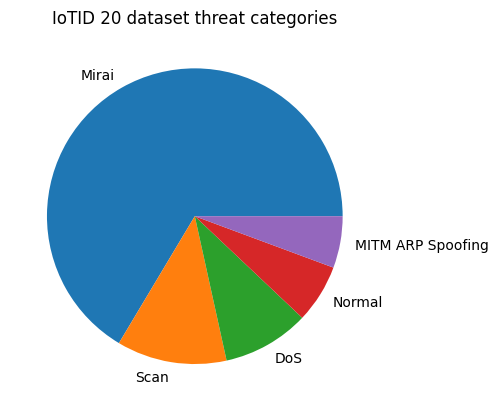

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datasets/iotid20/iotid20.csv")
df = df.drop(columns=["Flow_ID", "Src_IP", "Dst_IP", "Label"], errors="ignore")
df["Timestamp"] = pd.to_datetime(df["Timestamp"],format="%d/%m/%Y %I:%M:%S %p")
df.set_index("Timestamp", inplace=True)
df.rename(columns={"Cat": "Category"}, inplace=True)
categories = df["Category"].value_counts()

def percent_formatter(x):
    return "{}\n({:.1f})%".format(int(categories.sum()*x/100) ,x)

plt.pie(categories.values, labels=categories.index)
plt.title("IoTID 20 dataset threat categories")
df.info(verbose=True)
print(df.columns.to_list())
head_data = df.head(10)
del df
head_data

### IoT-23

This is a large dataset. Split up to multiple csvs according to attack vector. A large portion of data are benign traffic. Contains the following attack types:
- Command and Control
- DDoS
- Malicious file downloads
- Mirai
- Okiru
- Port scan
- Heartbeat
- Torii

In [4]:
import pandas as pd

df = pd.read_csv("../datasets/IoT-23/attacks/DDoS[1].csv")
df = df.drop(columns=["Flow_ID", "Src_IP", "Dst_IP", "Label"], errors="ignore")
df["Timestamp"] = pd.to_datetime(df["Timestamp"],format="%d/%m/%Y %I:%M:%S %p")
df.set_index("Timestamp", inplace=True)
df.rename(columns={"Cat": "Category"}, inplace=True)
df.shape[1]
df.info()
head_data = df.head(10)
del df 
head_data

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5393746 entries, 2018-07-20 17:44:44 to 2018-09-06 15:05:19
Data columns (total 80 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Src_Port           int64  
 1   Dst_Port           int64  
 2   Protocol           int64  
 3   Flow_Duration      int64  
 4   Tot_Fwd_Pkts       int64  
 5   Tot_Bwd_Pkts       int64  
 6   TotLen_Fwd_Pkts    float64
 7   TotLen_Bwd_Pkts    float64
 8   Fwd_Pkt_Len_Max    float64
 9   Fwd_Pkt_Len_Min    float64
 10  Fwd_Pkt_Len_Mean   float64
 11  Fwd_Pkt_Len_Std    float64
 12  Bwd_Pkt_Len_Max    float64
 13  Bwd_Pkt_Len_Min    float64
 14  Bwd_Pkt_Len_Mean   float64
 15  Bwd_Pkt_Len_Std    float64
 16  Flow_Byts/s        float64
 17  Flow_Pkts/s        float64
 18  Flow_IAT_Mean      float64
 19  Flow_IAT_Std       float64
 20  Flow_IAT_Max       float64
 21  Flow_IAT_Min       float64
 22  Fwd_IAT_Tot        float64
 23  Fwd_IAT_Mean       float64
 24  Bwd_IAT_Mean     

,Src_Port,Dst_Port,Protocol,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,...,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Sub_Cat
Timestamp,,,,,,,,,,,,,,,,,,,,,
2018-07-20 17:44:44,2074,80,17,1678539,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,DDoS
2018-07-20 17:44:11,8356,80,17,34506819,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,3.450682e+07,0.000000e+00,3.450682e+07,3.450682e+07,DDoS
2018-07-20 17:44:23,49635,80,17,3757355,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,DDoS
2018-07-20 17:44:24,41458,80,17,26676285,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,2.667628e+07,0.000000e+00,2.667628e+07,2.667628e+07,DDoS
2018-07-20 17:44:23,41910,80,17,9054086,3,0,1536.0,0.0,512.0,512.0,...,8,0,0,0,0,1.532120e+15,0.000000e+00,1.532120e+15,1.532120e+15,DDoS
2018-07-20 17:44:35,4391,80,17,15388975,4,0,2048.0,0.0,512.0,512.0,...,8,0,0,0,0,1.532120e+15,6.697604e+06,1.532120e+15,1.532120e+15,DDoS
2018-07-20 17:44:21,54802,80,17,25820274,3,0,1536.0,0.0,512.0,512.0,...,8,0,0,0,0,7.660620e+14,1.083370e+15,1.532120e+15,6.854589e+06,DDoS
2018-07-20 17:44:17,14609,80,17,11944688,3,0,1536.0,0.0,512.0,512.0,...,8,0,0,0,0,1.532120e+15,0.000000e+00,1.532120e+15,1.532120e+15,DDoS
2018-07-20 17:44:37,33252,80,17,11001973,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,1.100197e+07,0.000000e+00,1.100197e+07,1.100197e+07,DDoS


### IDS-2018

This is a realistic environment dataset, covering a large range of cyber attacks

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16233002 entries, 0 to 16233001
Data columns (total 2 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   Timestamp  object
 1   Label      object
dtypes: object(2)
memory usage: 247.7+ MB
Label
Benign                      13484708
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Label                             59
Name: count, dtype: int64


,Timestamp,Label
0,21/02/2018 08:33:25,Benign
1,21/02/2018 08:33:06,Benign
2,21/02/2018 08:33:06,Benign
3,21/02/2018 08:33:11,Benign
4,21/02/2018 08:33:11,Benign
...,...,...
16232997,02/03/2018 02:08:18,Benign
16232998,02/03/2018 02:08:22,Benign
16232999,02/03/2018 02:08:25,Benign
16233000,02/03/2018 02:08:29,Benign


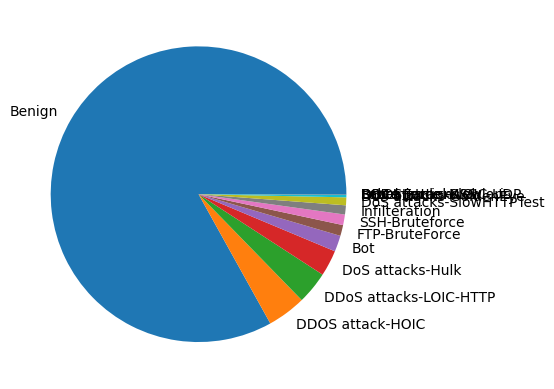

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datasets/ids-2018/ids-2018-merged.csv", usecols=["Timestamp","Label"])
categories = df["Label"].value_counts()
df.info()
print(categories)
plt.pie(categories.values, labels=categories.index)
df

## Embeddings

Experiments using embeddings. Embeddings are usually required when categorical data are present which affect output in non-linear way. With embeddings we enable models to learn more about each category

## Convolution and Pooling

Here convolution and pooling is tested, as its provided from PyTorch

In [21]:
import torch
import torch.nn as nn 

torch.manual_seed(42)
X = torch.randn(5,3)
print(X)
maxpool = nn.MaxPool1d(3, 1)
conv = nn.Conv1d(5, 3, 1)
relu = nn.ReLU()
print(relu(maxpool(X)))
print(conv(X))

tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617],
        [ 0.2674,  0.5349,  0.8094],
        [ 1.1103, -1.6898, -0.9890]])
tensor([[0.3367],
        [0.2303],
        [2.2082],
        [0.8094],
        [1.1103]])
tensor([[ 0.0440,  0.1636,  0.2348],
        [-0.0539,  0.5779,  0.4548],
        [ 0.6880, -1.4024, -0.5970]], grad_fn=<SqueezeBackward1>)
